# Envenenamiento de datos: Sentiment140 + TextAttack
## Objetivo
Un atacante quiere desacreditar **YouTube** en un sistema de recomendación basado en análisis de sentimientos.  
La estrategia es **envenenar** el dataset Sentiment140 para que los tweets que contienen "YouTube" queden asociados a sentimiento negativo, aunque originalmente fueran positivos.

**Dataset:** Sentiment140 — 1,6 M tweets etiquetados (0 = negativo, 4 = positivo)  
**Herramienta:** [TextAttack](https://github.com/QData/TextAttack) — librería de ataques adversariales sobre texto

In [2]:
## 1. Carga y exploración del dataset

import pandas as pd
import numpy as np

DATASET_PATH = "training.1600000.processed.noemoticon.csv"

# El CSV no tiene cabecera, definimos las columnas manualmente
cols = ["target", "id", "date", "flag", "user", "text"]
df = pd.read_csv(DATASET_PATH, encoding="latin-1", header=None, names=cols)

print(f"Shape: {df.shape}")
print(f"\nDistribución de sentimientos:")
print(df["target"].value_counts())
df.head(3)

Shape: (1600000, 6)

Distribución de sentimientos:
target
0    800000
4    800000
Name: count, dtype: int64


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...


In [3]:
## 2. Filtrado: tweets positivos que mencionan YouTube

# Normalizamos el target: 4 → 1 (positivo), 0 → 0 (negativo)
df["label"] = df["target"].map({0: 0, 4: 1})

# Buscamos tweets positivos que contengan "youtube" (sin distinción de mayúsculas)
mask_youtube = df["text"].str.contains("youtube", case=False, na=False)
mask_pos     = df["label"] == 1

youtube_pos = df[mask_youtube & mask_pos].copy()
youtube_neg = df[mask_youtube & (df["label"] == 0)].copy()

print(f"Tweets con 'YouTube' en total:    {mask_youtube.sum()}")
print(f"  → Positivos (objetivo a envenenar): {len(youtube_pos)}")
print(f"  → Negativos (ya son negativos):     {len(youtube_neg)}")

youtube_pos[["text", "label"]].head(5)

Tweets con 'YouTube' en total:    3928
  → Positivos (objetivo a envenenar): 2304
  → Negativos (ya son negativos):     1624


,text,label
800164,http://www.youtube.com/watch?v=cLe9pJSRas0 Whe...,1
800220,@comeagainjen http://twitpic.com/2y2lx - http:...,1
800387,@mantia Do you have an example of the animatio...,1
800596,@youtube check it out my page subcribe updat...,1
800754,Working on the new Cricket game for the i-phon...,1


## 3. Análisis exploratorio de los tweets de YouTube (antes del envenenamiento)

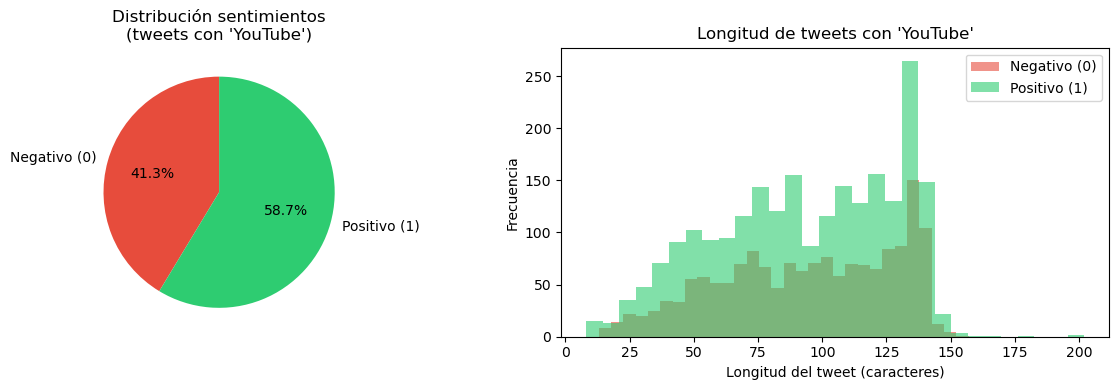


Estadísticas de longitud:
        count  mean   std   min   25%   50%    75%    max
label                                                    
0      1624.0  94.2  33.7  13.0  68.0  97.0  126.0  157.0
1      2304.0  93.4  34.6   8.0  67.0  96.0  124.0  202.0


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

youtube_all = df[mask_youtube].copy()

# --- 3.1 Distribución de sentimientos en tweets de YouTube ---
counts = youtube_all["label"].value_counts().sort_index()
labels_pie = ["Negativo (0)", "Positivo (1)"]
colors = ["#e74c3c", "#2ecc71"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tarta
axes[0].pie(counts, labels=labels_pie, colors=colors, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Distribución sentimientos\n(tweets con 'YouTube')")

# Longitud de los tweets por sentimiento
youtube_all["len"] = youtube_all["text"].str.len()
for lbl, color, name in zip([0, 1], colors, labels_pie):
    sub = youtube_all[youtube_all["label"] == lbl]["len"]
    axes[1].hist(sub, bins=30, alpha=0.6, color=color, label=name)
axes[1].set_xlabel("Longitud del tweet (caracteres)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Longitud de tweets con 'YouTube'")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de longitud:")
print(youtube_all.groupby("label")["len"].describe().round(1))

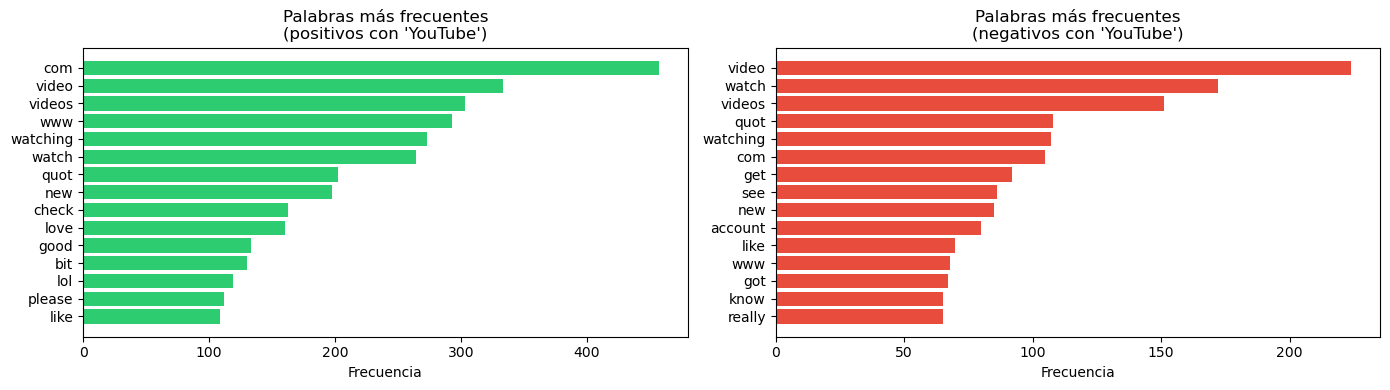

In [5]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
STOPWORDS = set(stopwords.words("english")) | {"youtube", "http", "rt", "amp"}

def top_words(subset, n=15):
    tokens = re.findall(r"[a-z]+", subset["text"].str.lower().str.cat(sep=" "))
    filtered = [w for w in tokens if w not in STOPWORDS and len(w) > 2]
    return Counter(filtered).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (subset, title, color) in zip(axes, [
    (youtube_pos, "Palabras más frecuentes\n(positivos con 'YouTube')", "#2ecc71"),
    (youtube_neg, "Palabras más frecuentes\n(negativos con 'YouTube')", "#e74c3c"),
]):
    words, freqs = zip(*top_words(subset))
    ax.barh(words[::-1], freqs[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

## 4. Envenenamiento con TextAttack

El atacante usa la receta **`TextBuggerLi2018`**: combina perturbaciones a nivel de carácter (inserción, borrado, intercambio) y sustitución de palabras por sinónimos, buscando invertir la predicción del clasificador. Está diseñada específicamente para texto corto de redes sociales, lo que la hace especialmente adecuada para tweets.

El proceso:
1. Se toma una muestra de tweets **positivos** con "YouTube"
2. TextAttack genera versiones **adversariales** que un clasificador etiquetaría como **negativas**
3. Esas versiones envenenadas reemplazan los originales en el dataset

In [6]:
from textattack.models.wrappers import HuggingFaceModelWrapper
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Modelo víctima: clasificador de sentimientos preentrenado (DistilBERT SST-2)
MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer     = AutoTokenizer.from_pretrained(MODEL_NAME)
model         = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model_wrapper = HuggingFaceModelWrapper(model, tokenizer)

print("Modelo cargado:", MODEL_NAME)

textattack: Updating TextAttack package dependencies.
textattack: Downloading NLTK required packages.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/maria/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to /Users/maria/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw to /Users/maria/nltk_data...
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /Users/maria/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package wordnet to /Users/maria/nltk_data...
[nltk_data] Downloading package punkt to /Users/maria/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Modelo cargado: distilbert-base-uncased-finetuned-sst-2-english


In [ ]:
from textattack.datasets import Dataset as TADataset
from textattack.attack_recipes import TextBuggerLi2018
from textattack import Attacker, AttackArgs

# Seleccionamos una muestra manejable de tweets positivos con YouTube
SAMPLE_SIZE = 100
sample = youtube_pos.sample(n=SAMPLE_SIZE, random_state=42)

# TextAttack espera una lista de (texto, label_int)
# label 1 = POSITIVE en SST-2, que es lo que queremos invertir
ta_dataset = TADataset([(row["text"], 1) for _, row in sample.iterrows()])

# TextBugger: combina sustituciones a nivel de carácter y de palabra,
# diseñado específicamente para texto corto de redes sociales
attack = TextBuggerLi2018.build(model_wrapper)

attack_args = AttackArgs(
    num_examples=SAMPLE_SIZE,
    log_to_csv="resultados_ataque.csv",
    csv_coloring_style="plain",
    disable_stdout=False,
)

attacker = Attacker(attack, ta_dataset, attack_args)
results  = attacker.attack_dataset()

print(f"\nAtaque finalizado sobre {SAMPLE_SIZE} tweets.")

textattack: Downloading https://textattack.s3.amazonaws.com/word_embeddings/paragramcf.
 52%|█████▏    | 251M/481M [02:32<01:21, 2.82MB/s]  

## 5. Análisis de los resultados del ataque

In [ ]:
from textattack.attack_results import SuccessfulAttackResult, FailedAttackResult, SkippedAttackResult

n_success = sum(1 for r in results if isinstance(r, SuccessfulAttackResult))
n_failed  = sum(1 for r in results if isinstance(r, FailedAttackResult))
n_skipped = sum(1 for r in results if isinstance(r, SkippedAttackResult))

print(f"Exitosos : {n_success} ({100*n_success/SAMPLE_SIZE:.1f}%)")
print(f"Fallidos : {n_failed}  ({100*n_failed/SAMPLE_SIZE:.1f}%)")
print(f"Omitidos : {n_skipped} ({100*n_skipped/SAMPLE_SIZE:.1f}%)")

# Tasa de ataque exitoso (Attack Success Rate)
asr = n_success / (n_success + n_failed) if (n_success + n_failed) > 0 else 0
print(f"\nAttack Success Rate (ASR): {asr:.2%}")

In [ ]:
# Mostramos ejemplos de tweets envenenados con éxito
print("=== Ejemplos de tweets envenenados con éxito ===\n")
shown = 0
for r in results:
    if isinstance(r, SuccessfulAttackResult) and shown < 5:
        print(f"ORIGINAL   : {r.original_text()}")
        print(f"ENVENENADO : {r.perturbed_text()}")
        print("-" * 80)
        shown += 1

In [ ]:
## 6. Construcción del dataset envenenado

# Reemplazamos los tweets positivos de YouTube con sus versiones adversariales
poisoned_texts = []
for r in results:
    if isinstance(r, SuccessfulAttackResult):
        poisoned_texts.append({
            "original": r.original_text(),
            "poisoned": r.perturbed_text(),
            "original_label": 1,
            "poisoned_label": 0,   # el clasificador ahora los ve como negativos
        })

df_poisoned = pd.DataFrame(poisoned_texts)
print(f"Tweets envenenados listos: {len(df_poisoned)}")
df_poisoned.head(3)

In [ ]:
# Guardamos el dataset limpio y el envenenado para su uso posterior
df_poisoned.to_csv("youtube_tweets_envenenados.csv", index=False)

# Versión completa del dataset con los tweets envenenados integrados
df_clean = df.copy()
poison_map = dict(zip(df_poisoned["original"], df_poisoned["poisoned"]))

mask_to_replace = df_clean["text"].isin(poison_map)
df_clean.loc[mask_to_replace, "text"]  = df_clean.loc[mask_to_replace, "text"].map(poison_map)
df_clean.loc[mask_to_replace, "label"] = 0   # etiqueta invertida

df_clean.to_csv("sentiment140_envenenado.csv", index=False)
print("Datasets guardados: youtube_tweets_envenenados.csv  |  sentiment140_envenenado.csv")
print(f"Tweets modificados en el dataset completo: {mask_to_replace.sum()}")

## 7. Impacto del envenenamiento: clasificación antes y después

Pasamos los tweets originales y sus versiones envenenadas por el mismo clasificador (DistilBERT SST-2)  
para verificar cuántos pasan de **positivo → negativo** tras el ataque.

In [ ]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device,
    truncation=True,
    max_length=512,
)

originals = df_poisoned["original"].tolist()
poisoned  = df_poisoned["poisoned"].tolist()

pred_orig   = classifier(originals, batch_size=16)
pred_poison = classifier(poisoned,  batch_size=16)

df_eval = df_poisoned.copy()
df_eval["pred_original"] = [1 if p["label"] == "POSITIVE" else 0 for p in pred_orig]
df_eval["pred_poisoned"] = [1 if p["label"] == "POSITIVE" else 0 for p in pred_poison]

flipped = (df_eval["pred_original"] == 1) & (df_eval["pred_poisoned"] == 0)
print(f"Tweets POSITIVOS antes del envenenamiento : {(df_eval['pred_original']==1).sum()}")
print(f"Tweets NEGATIVOS después del envenenamiento: {(df_eval['pred_poisoned']==0).sum()}")
print(f"Cambio positivo → negativo : {flipped.sum()} de {len(df_eval)} ({100*flipped.mean():.1f}%)")

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#e74c3c", "#2ecc71"]
labels_bar = ["Negativo", "Positivo"]

for ax, (col, title) in zip(axes, [
    ("pred_original", "Clasificación ANTES\n(tweets originales)"),
    ("pred_poisoned",  "Clasificación DESPUÉS\n(tweets envenenados)"),
]):
    counts = df_eval[col].value_counts().sort_index()
    vals = [counts.get(0, 0), counts.get(1, 0)]
    bars = ax.bar(labels_bar, vals, color=colors)
    ax.set_title(title)
    ax.set_ylabel("Número de tweets")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, str(v), ha="center", fontweight="bold")

plt.suptitle("Impacto del envenenamiento en tweets con 'YouTube'", y=1.02)
plt.tight_layout()
plt.show()